In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('adult.csv')

In [15]:
print(df.head())
print(df.info())

   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18  United-States

In [16]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols)


Categorical Columns: Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='object')


In [17]:
ordinal_col = ['education']
nominal_cols = [col for col in categorical_cols if col not in ordinal_col]


In [18]:
le = LabelEncoder()

for col in ordinal_col:
    df[col] = le.fit_transform(df[col])


In [19]:
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)


In [20]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns


In [21]:
scaler_std = StandardScaler()
df_standardized = df.copy()
df_standardized[numerical_cols] = scaler_std.fit_transform(df[numerical_cols])


In [22]:
scaler_minmax = MinMaxScaler()
df_normalized = df.copy()
df_normalized[numerical_cols] = scaler_minmax.fit_transform(df[numerical_cols])


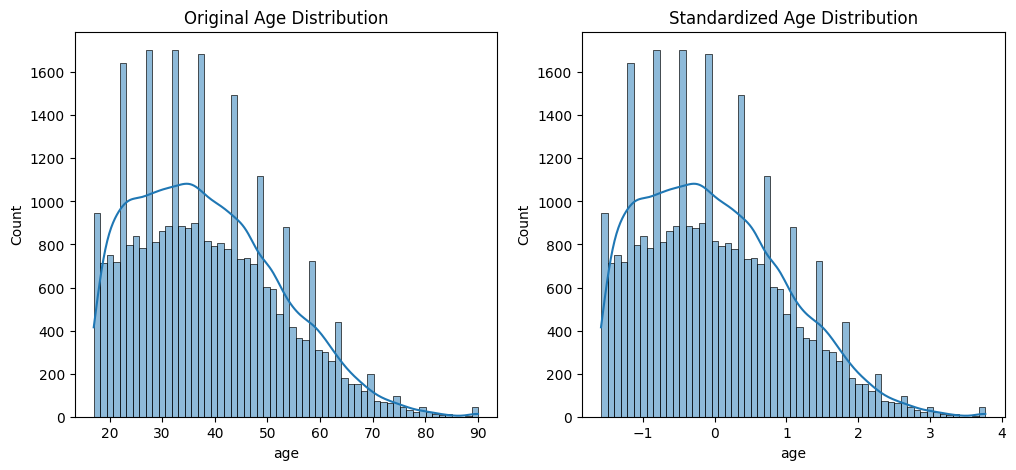

In [23]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['age'], kde=True)
plt.title("Original Age Distribution")

plt.subplot(1,2,2)
sns.histplot(df_standardized['age'], kde=True)
plt.title("Standardized Age Distribution")

plt.show()